In [2]:
import numpy as np
import pickle
import os
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import urllib.request as request
import tarfile
import matplotlib.pyplot as plt

In [3]:
# CIFAR-10 Download
def download_cifar10(data_dir="./cifar-10-batches-py"):
    if not os.path.exists(data_dir):
        url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
        request.urlretrieve(url, "cifar-10.tar.gz")
        with tarfile.open("cifar-10.tar.gz") as tar:
            tar.extractall(".")
        os.remove("cifar-10.tar.gz")
    return data_dir

# CIFAR data stored as pickle format
# convert to byte data
def load_batch(filepath):
    with open(filepath, "rb") as f:
        batch = pickle.load(f, encoding="bytes")
    images = batch[b"data"]           # (10000, 3072)  uint8
    labels = np.array(batch[b"labels"])  # (10000,)
    return images, labels


def load_cifar10(data_dir="./cifar-10-batches-py"):
    train_images, train_labels = [], []

    for i in range(1, 6):
        path = os.path.join(data_dir, f"data_batch_{i}")
        imgs, lbls = load_batch(path)
        train_images.append(imgs)
        train_labels.append(lbls)

    X_train = np.concatenate(train_images, axis=0)
    y_train = np.concatenate(train_labels, axis=0)

    X_test, y_test = load_batch(os.path.join(data_dir, "test_batch"))

    return X_train, y_train, X_test, y_test

In [ ]:
# download data
data_dir = download_cifar10()
X_train, y_train, X_test, y_test = load_cifar10(data_dir)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test : {X_test.shape},  y_test : {y_test.shape}")

X_train: (50000, 3072), y_train: (50000,)
X_test : (10000, 3072),  y_test : (10000,)


image : 32 * 32 * 3 (RGB) => Flatten => 3072 columns

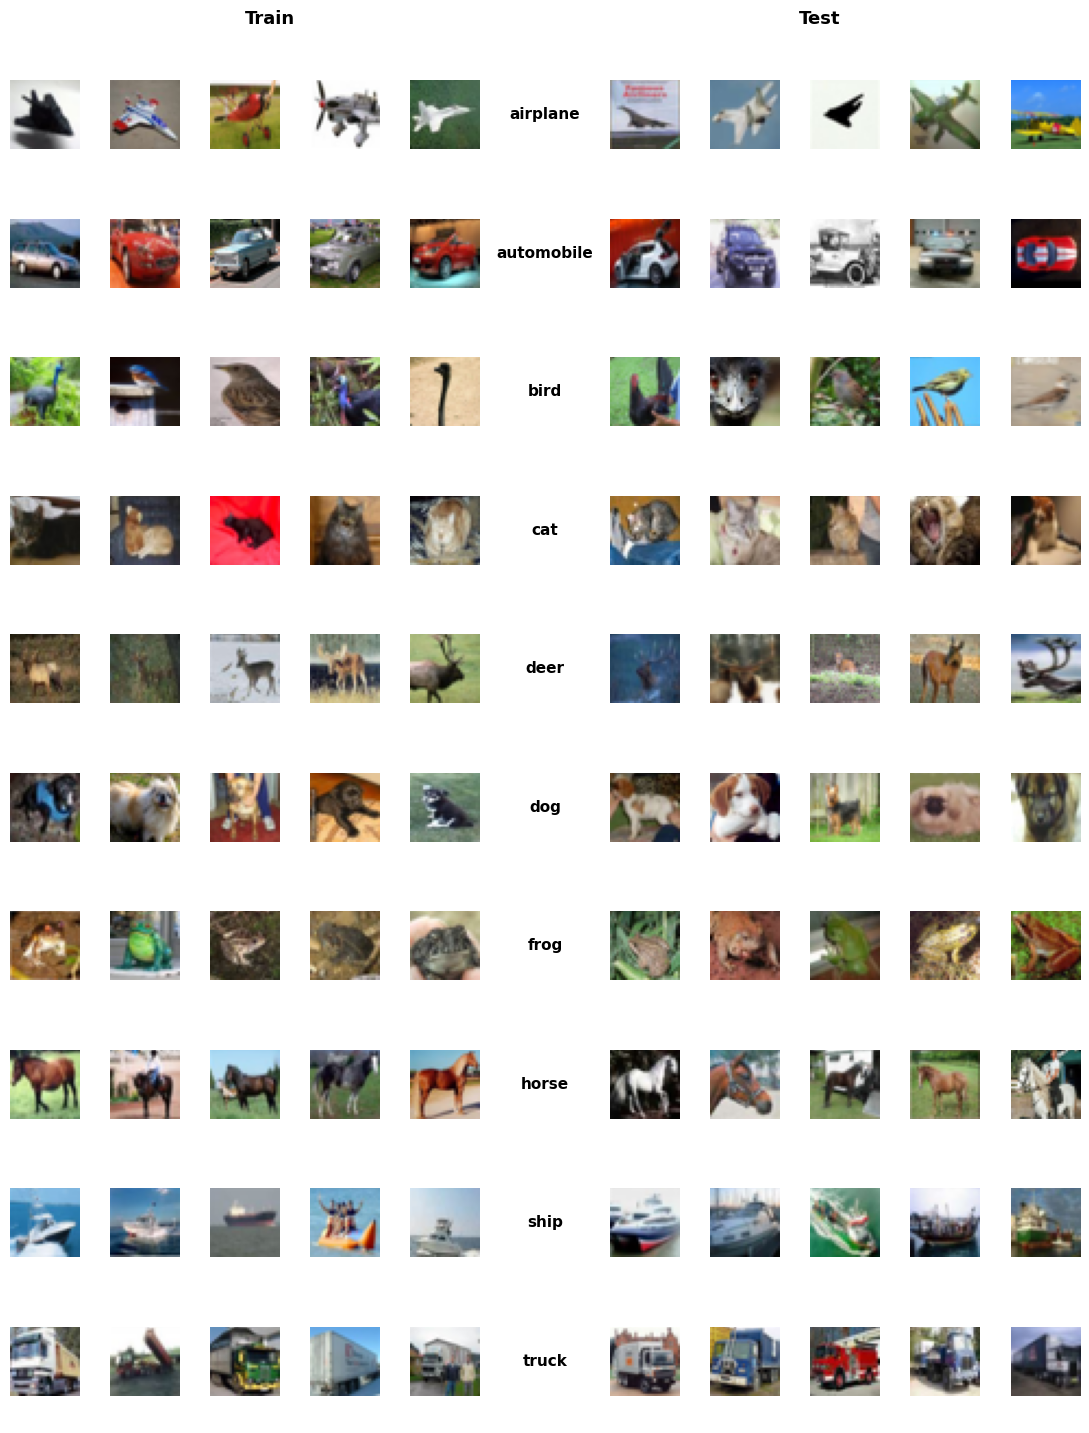

In [ ]:
# 10 classes
CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

def show_images_per_class_both(X_train, y_train, X_test, y_test, num_per_class=5):
    total_cols = 2 * num_per_class + 1 # col : (train images + title + test images)
    fig, axes = plt.subplots(10, total_cols, figsize=(total_cols, 14))

    for class_idx in range(10): # label
        train_indices = np.where(y_train == class_idx)[0][:num_per_class]
        test_indices  = np.where(y_test  == class_idx)[0][:num_per_class]

        for col, img_idx in enumerate(train_indices):
            # flatten(3072) => 3 * 32 * 32 (image) => 32 * 32 * 3
            img = X_train[img_idx].reshape(3, 32, 32).transpose(1, 2, 0)
            axes[class_idx, col].imshow(img)
            axes[class_idx, col].axis('off')

        mid = num_per_class
        axes[class_idx, mid].axis('off')
        axes[class_idx, mid].text(
            0.5, 0.5,
            CLASSES[class_idx],
            transform=axes[class_idx, mid].transAxes,
            fontsize=11, fontweight='bold',
            va='center', ha='center'
        )

        for col, img_idx in enumerate(test_indices):
            # flatten(3072) => 3 * 32 * 32 (image) => 32 * 32 * 3
            img = X_test[img_idx].reshape(3, 32, 32).transpose(1, 2, 0)
            axes[class_idx, num_per_class + 1 + col].imshow(img)
            axes[class_idx, num_per_class + 1 + col].axis('off')

    fig.text(0.25, 1.00, "Train", ha='center', fontsize=13, fontweight='bold')
    fig.text(0.75, 1.00, "Test",  ha='center', fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()

show_images_per_class_both(X_train, y_train, X_test, y_test, num_per_class=5)

In [ ]:
def compare_k(X_train, y_train, X_test, y_test, k_list):
    results = {}
    for k in k_list:
        knn = KNeighborsClassifier(
            n_neighbors=k,
            metric="manhattan"
        )
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results[k] = acc
        print(f"  k={k:3d}  →  accuracy = {acc:.4f} ({acc*100:.2f}%)")

    best_k = max(results, key=results.get)
    print(f"\n  Optimal k = {best_k}  (accuracy {results[best_k]*100:.2f}%)")

    return results  

In [ ]:
# compare_k(X_train, y_train, X_test, y_test, k_list=[1, 5, 15])
 
# Takes too long, so only testing with 1000 samples
compare_k(X_train, y_train, X_test[:1000], y_test[:1000], k_list=[1, 5, 15])

  k=  1  →  accuracy = 0.4040 (40.40%)
  k=  5  →  accuracy = 0.3940 (39.40%)
  k= 15  →  accuracy = 0.3730 (37.30%)

  Optimal k = 1  (accuracy 40.40%)


{1: 0.404, 5: 0.394, 15: 0.373}